In [1]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # paretto 80% - 20% pruebas
from sklearn.linear_model import LinearRegression # invocacion del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score # Generaciond de metricas


In [2]:
# Cargar el conjunto de datos que esta en la  Api de boston inmobiliaria
data_url = "https://lib.stat.cmu.edu/datasets/boston"
df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# procesamiento de datos
data = np.hstack([df.values[::2, :], df.values[1::2, :2]]) # concatenar filas pares e inpares
target = df.values[1::2, 2] # Seleccion de variables objetivo

#creacion de dataframe
df_original = pd.DataFrame(data, columns=[
    "CRIM", 'ZN', 'INDUS', 'CHAS','NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
    ]) # Variables independientes
df_original['PRICE'] = target # Variable dependiente

df_original




<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5001/3226097175.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


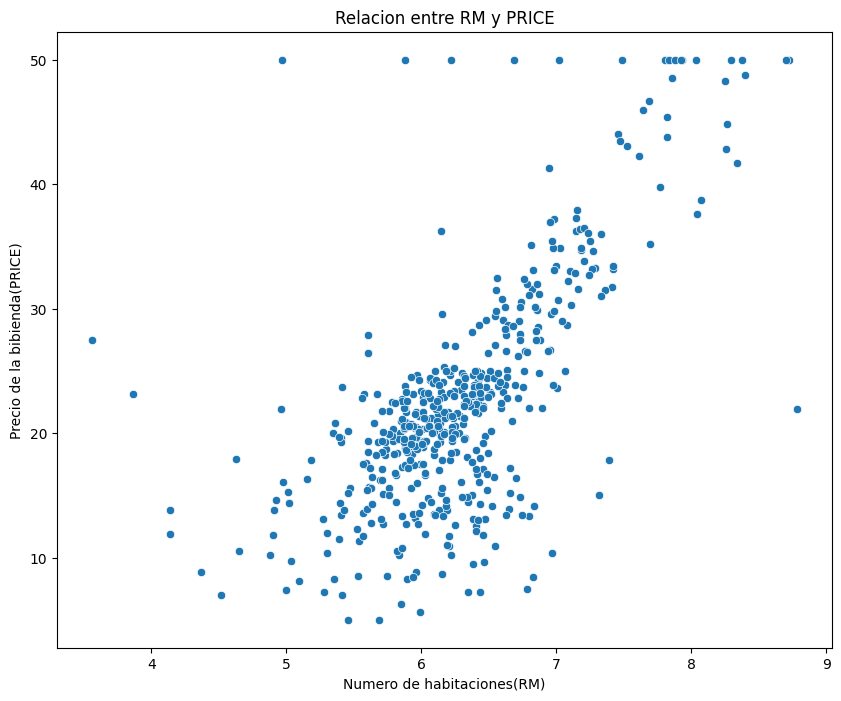

In [3]:
# Analisis exploratorio de datos
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_original['RM'], y=df_original['PRICE'])
plt.title('Relacion entre RM y PRICE')
plt.xlabel('Numero de habitaciones(RM)')
plt.ylabel('Precio de la bibienda(PRICE)')
plt.show()

#Division del set de datos

X = df_original.drop('PRICE', axis=1)
y = df_original['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# ALgoritmo de Regresion lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones (Canon de arrendanmiento )
y_pred = model.predict(X_test)

# evaluacion del modelo

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 24.29
Mean Absolute Error: 3.19
R-squared: 0.67


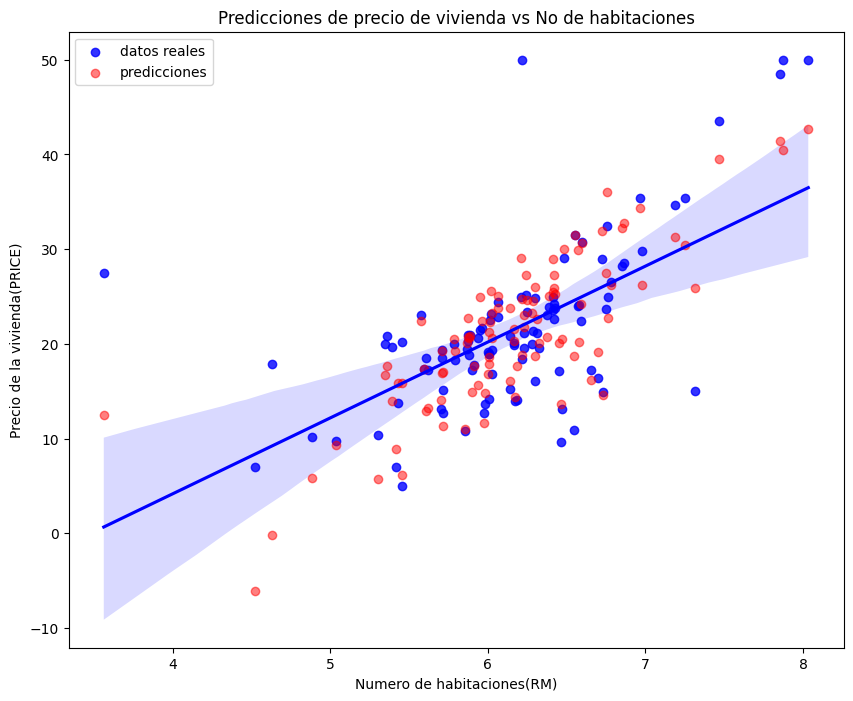

In [5]:
# Grafico de Regrecion Lineal
plt.figure(figsize=(10, 8))
sns.regplot(x=X_test['RM'], y=y_test, marker='o', label='datos reales', color='blue')
plt.scatter(X_test['RM'], y_pred, color='red', label='predicciones', alpha=0.5)
plt.title('Predicciones de precio de vivienda vs No de habitaciones')
plt.xlabel('Numero de habitaciones(RM)')
plt.ylabel('Precio de la vivienda(PRICE)')
plt.legend()
plt.show()


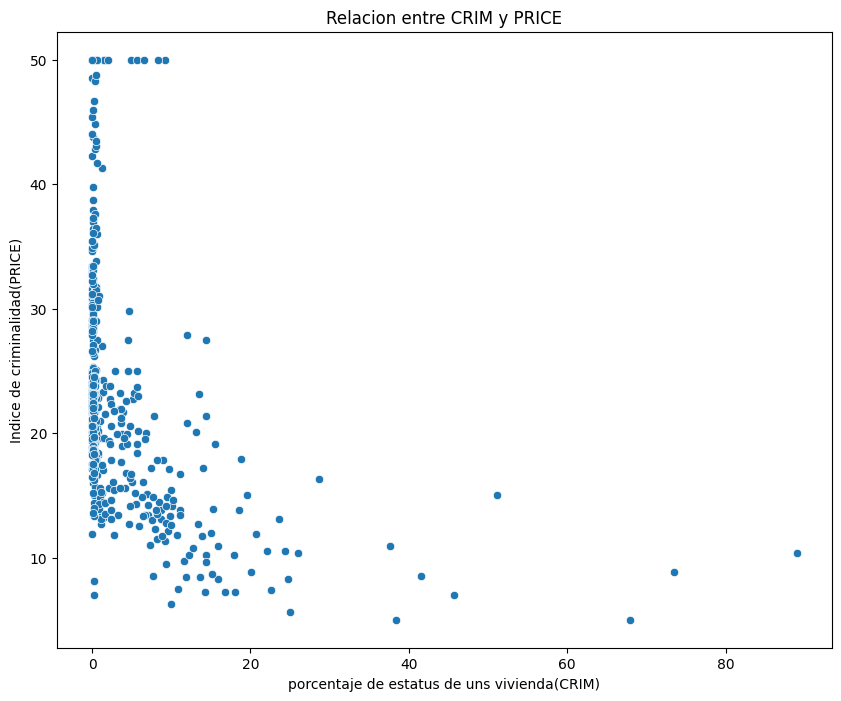

In [6]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_original['CRIM'], y=df_original['PRICE'])
plt.title('Relacion entre CRIM y PRICE')
plt.xlabel('porcentaje de estatus de uns vivienda(CRIM)')
plt.ylabel('Indice de criminalidad(PRICE)')
plt.show()


X = df_original.drop('PRICE', axis=1)
y = df_original['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones (Canon de arrendanmiento )
y_pred = model.predict(X_test)

# evaluacion del modelo

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 24.29
Mean Absolute Error: 3.19
R-squared: 0.67


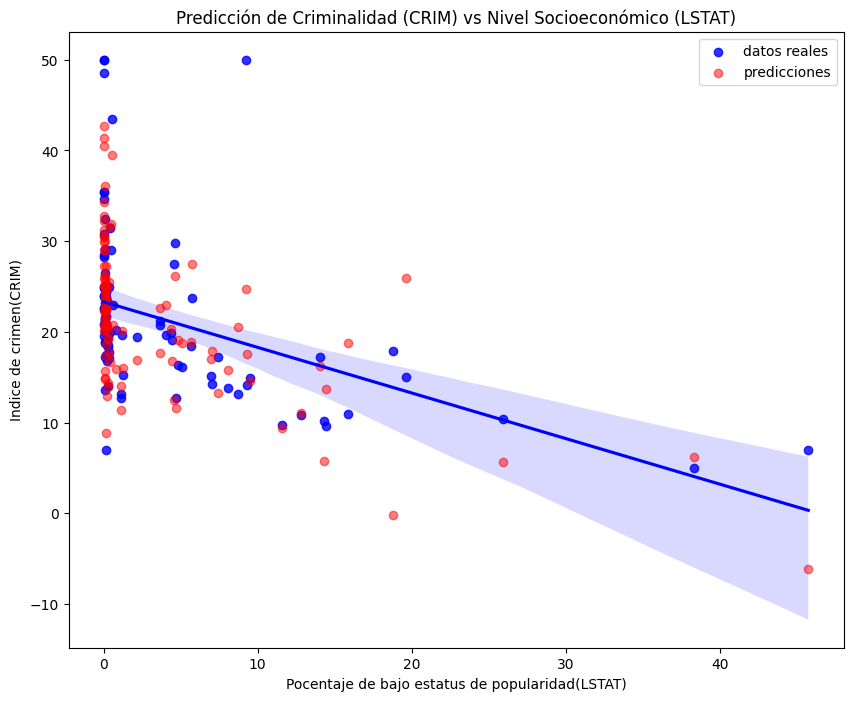

In [8]:
# Grafico de Regrecion Lineal
plt.figure(figsize=(10, 8))
sns.regplot(x=X_test['CRIM'], y=y_test, marker='o', label='datos reales', color='blue')
plt.scatter(X_test['CRIM'], y_pred, color='red', label='predicciones', alpha=0.5)
plt.title('Predicción de Criminalidad (CRIM) vs Nivel Socioeconómico (LSTAT)')
plt.xlabel('Pocentaje de bajo estatus de popularidad(LSTAT)')
plt.ylabel('Indice de crimen(CRIM)')
plt.legend()
plt.show()